In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 🧠 Brain Tumor Classification from MRI Scans Using Deep Learning

## 🌟 Introduction

### Context
Brain tumors are among the most critical health challenges, with early detection being crucial for effective treatment. This project explores automated tumor classification using MRI scans through deep learning techniques. With over 3,000 MRI scans across 4 tumor categories, we aim to build robust models that can assist medical professionals in rapid diagnosis.

### 🎯 Objective
- Develop and compare CNN architectures for tumor classification
- Implement transfer learning with state-of-the-art models
- Create reproducible pipeline for medical image analysis
- Achieve >90% validation accuracy

### 📂 Dataset Overview
- **Source**: [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)
- **Classes** (4 categories):
  - Glioma Tumor
  - Meningioma Tumor
  - Pituitary Tumor
  - No Tumor
- **Image Specifications**:
  - 3-channel RGB
  - 224×224 resolution
  - Preprocessed and labeled

### 🔑 Key Features
- **Custom CNN Architectures**: Two novel neural network designs
- **Transfer Learning**: Fine-tuned EfficientNet-B0
- **Advanced Augmentation**: Rotation, flipping, color jitter
- **Model Interpretability**: Performance metrics

---

## 🔧 Environment Configuration & Setup

---

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import ImageFolder


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


import warnings
warnings.filterwarnings('ignore')


def seed_everything(seed: int) -> None:
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.backends.cudnn.deterministic = True

seed_everything(0xBADBEEF)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 
    'mps' if torch.has_mps else 
    'cpu'
)
print(f"Accelerator: {device} | Torch {torch.__version__}")

Accelerator: cuda | Torch 2.5.1+cu121


## 🔄 Image Transformations Pipeline
**Augmentation Strategy for Robust Training:**

* Standardize image size

* Mirror images randomly (50% chance)
 
* Rotate ±10 degrees for orientation invariance

* Convert to [C, H, W] tensor format

* ImageNet stats normalization

---

In [3]:
transform_ = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = ImageFolder(
    '/kaggle/input/brain-tumor-mri-dataset/Training',
    transform=transform_,
)

val_dataset = ImageFolder(
    '/kaggle/input/brain-tumor-mri-dataset/Testing',
    transform=transform_,
)

## Dataset Visualization & Sample Exploration

### Purpose
Visual quality control of preprocessed MRI scans to:
- Verify correct data augmentation
- Validate class label associations
- Inspect image normalization effects
- Detect potential data anomalies

---

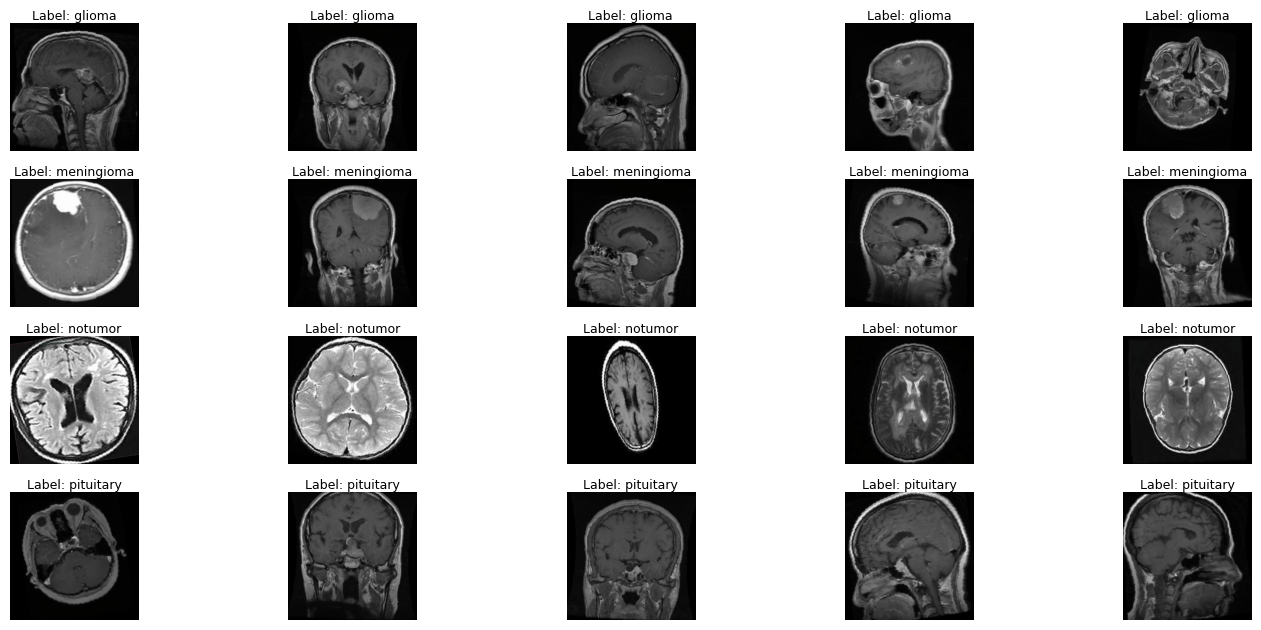

In [4]:
def visualize_samples(dataset, num_samples=5, mean=(0.5, 0.5, 0.5), 
                     std=(0.5, 0.5, 0.5), figsize=(15, 10), 
                     show_labels=True):
    class_examples = {}
    class_counts = {}
    
    try:
        classes = dataset.classes
        for cls in classes:
            class_examples[cls] = []
            class_counts[cls] = 0
    except AttributeError:
        classes = list(set(dataset.targets))
        for cls in classes:
            class_examples[cls] = []
            class_counts[cls] = 0

    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    for images, labels in loader:
        for img, label in zip(images, labels):
            cls = classes[label.item()] if isinstance(classes, list) else label.item()
            if class_counts[cls] < num_samples:
                class_examples[cls].append((img, cls))
                class_counts[cls] += 1
        
        if all(v >= num_samples for v in class_counts.values()):
            break

    n_classes = len(class_examples)
    
    fig, axes = plt.subplots(
        nrows=n_classes,
        ncols=num_samples,
        figsize=(figsize[0], figsize[1] * n_classes / 5),
        squeeze=False
    )
    
    for row_idx, (cls_name, examples) in enumerate(class_examples.items()):
        for col_idx in range(num_samples):
            ax = axes[row_idx, col_idx]
            
            if col_idx >= len(examples):
                ax.axis('off')
                continue
                
            img, label = examples[col_idx]
            
            if torch.is_tensor(img):
                img = img.numpy()
            
            if img.shape[0] in [1, 3]:
                img = img.transpose(1, 2, 0)
            
            img = img * np.array(std) + np.array(mean)
            img = np.clip(img, 0, 1)
            
            cmap = 'gray' if img.shape[-1] == 1 else None
            ax.imshow(img.squeeze() if cmap else img, cmap=cmap)
            ax.axis('off')
            
            if show_labels:
                ax.set_title(f"Label: {label}", fontsize=9, pad=2)

    plt.tight_layout()
    plt.show()

visualize_samples(
    train_dataset,
    num_samples=5,
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
    figsize=(15, 8)
)

## Class Distribution Analysis

---

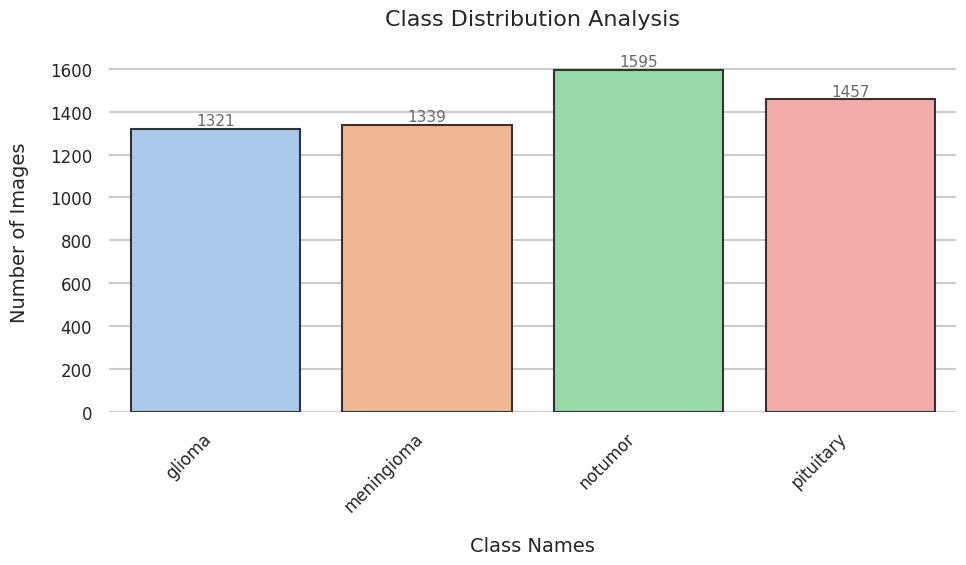

In [5]:
def plot_class_distribution(dataset):
    labels = [label for _, label in dataset]
    class_counts = Counter(labels)
    class_names = dataset.classes
    counts = [class_counts[i] for i in range(len(class_names))]

    sns.set(style="whitegrid", context="talk", palette="pastel")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(x=class_names, y=counts, edgecolor=".2", linewidth=1.5)
    
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 3,
                f'{int(height)}',
                ha='center', va='bottom',
                fontsize=11,
                color='dimgrey')

    ax.set_title('Class Distribution Analysis', fontsize=16, pad=20)
    ax.set_xlabel('Class Names', fontsize=14, labelpad=15)
    ax.set_ylabel('Number of Images', fontsize=14, labelpad=15)
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    if max(len(name) for name in class_names) > 8:
        plt.xticks(rotation=45, ha='right')

    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

plot_class_distribution(train_dataset)

## Core Training Pipeline

---

In [6]:
def train(
    train_loader: DataLoader,
    test_loader: DataLoader,
    num_epochs: int = 50,
    learning_rate: float = 0.001,
    model: nn.Module = None,
    optimizer: torch.optim.Optimizer = None,
    criterion: nn.Module = None,
    device: torch.device = None,
) -> tuple[nn.Module, dict]:
    
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    try:
        class_names = train_loader.dataset.classes
    except AttributeError:
        class_names = [str(i) for i in range(len(torch.unique(train_loader.dataset.targets)))]
    
    history = {
        'train_loss': [],
        'test_loss': [],
        'metrics': {
            'accuracy': [],
            'precision': [],
            'recall': [],
            'f1': []
        }
    }

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        model.eval()
        test_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                
                probs = F.softmax(outputs, dim=1)
                preds = torch.argmax(probs, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        
        history['train_loss'].append(train_loss/len(train_loader))
        history['test_loss'].append(test_loss/len(test_loader))
        history['metrics']['accuracy'].append(accuracy)
        history['metrics']['precision'].append(precision)
        history['metrics']['recall'].append(recall)
        history['metrics']['f1'].append(f1)

        if (epoch + 1) % 2 == 0:
            print(f"\nEpoch {epoch+1}/{num_epochs}")
            print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))
            print("-"*50)

    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['test_loss'], label='Test Loss')
    plt.title('Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    metrics_data = [
        ["Accuracy", history['metrics']['accuracy'][-1]],
        ["Precision", history['metrics']['precision'][-1]],
        ["Recall", history['metrics']['recall'][-1]],
        ["F1 Score", history['metrics']['f1'][-1]]
    ]
    
    table = plt.table(
        cellText=[[f"{val:.4f}"] for (_, val) in metrics_data],
        rowLabels=[name for (name, _) in metrics_data],
        colLabels=['Value'],
        loc='center',
        cellLoc='center',
        bbox=[0.2, 0.1, 0.6, 0.8]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    plt.axis('off')
    plt.title('Final Metrics')
    
    plt.tight_layout()
    plt.show()

    return model, history

In [24]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
)

## Custom CNN Architecture: TumorClassifierV1

### 🏗️ Model Architecture Design

---

In [8]:
class Tumor_Classifier(nn.Module):
    def __init__(self, 
                 num_classes: int = 4,
                 dropout_p: float = 0.2,
                 in_channels: int = 3,
                 hidden_dim: int = 128):
        super().__init__()
        
        self.feature_extractor = nn.Sequential(
            # Input: (3, 224, 224)
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (32, 112, 112)
            
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # (16, 56, 56)
            
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((16, 16))  # (8, 16, 16)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 16 * 16, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)


Epoch 2/40
              precision    recall  f1-score   support

      glioma       0.80      0.78      0.79       300
  meningioma       0.70      0.50      0.58       306
     notumor       0.84      0.95      0.89       405
   pituitary       0.85      0.97      0.90       300

    accuracy                           0.81      1311
   macro avg       0.80      0.80      0.79      1311
weighted avg       0.80      0.81      0.80      1311

--------------------------------------------------

Epoch 4/40
              precision    recall  f1-score   support

      glioma       0.84      0.85      0.84       300
  meningioma       0.79      0.58      0.67       306
     notumor       0.86      0.99      0.92       405
   pituitary       0.91      0.96      0.93       300

    accuracy                           0.85      1311
   macro avg       0.85      0.84      0.84      1311
weighted avg       0.85      0.85      0.85      1311

--------------------------------------------------

Epo

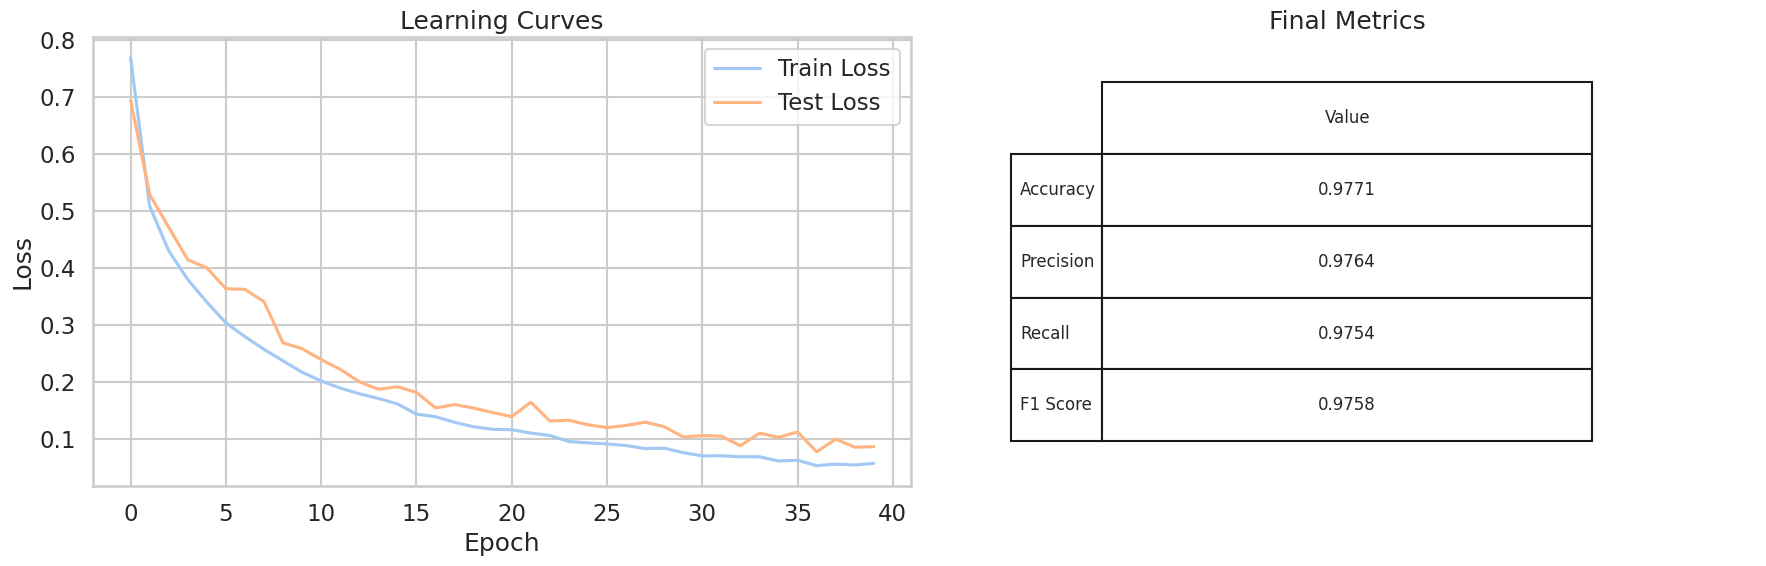

In [9]:
model = Tumor_Classifier(num_classes=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

trained_model, history = train(
    train_dataloader,
    val_dataloader,
    num_epochs=40,
    model=model,
    optimizer=optimizer,
    criterion=criterion
)

## Compact CNN Architecture: TumorClassifierV2

### Simplified Model Design

---

In [12]:
class Tumor_Classifier2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(32 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1) 
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x


Epoch 2/20
              precision    recall  f1-score   support

      glioma       0.79      0.86      0.82       300
  meningioma       0.76      0.69      0.72       306
     notumor       0.93      0.91      0.92       405
   pituitary       0.90      0.95      0.92       300

    accuracy                           0.85      1311
   macro avg       0.85      0.85      0.85      1311
weighted avg       0.85      0.85      0.85      1311

--------------------------------------------------

Epoch 4/20
              precision    recall  f1-score   support

      glioma       0.90      0.81      0.85       300
  meningioma       0.79      0.83      0.81       306
     notumor       0.94      0.97      0.95       405
   pituitary       0.95      0.96      0.96       300

    accuracy                           0.90      1311
   macro avg       0.90      0.89      0.89      1311
weighted avg       0.90      0.90      0.90      1311

--------------------------------------------------

Epo

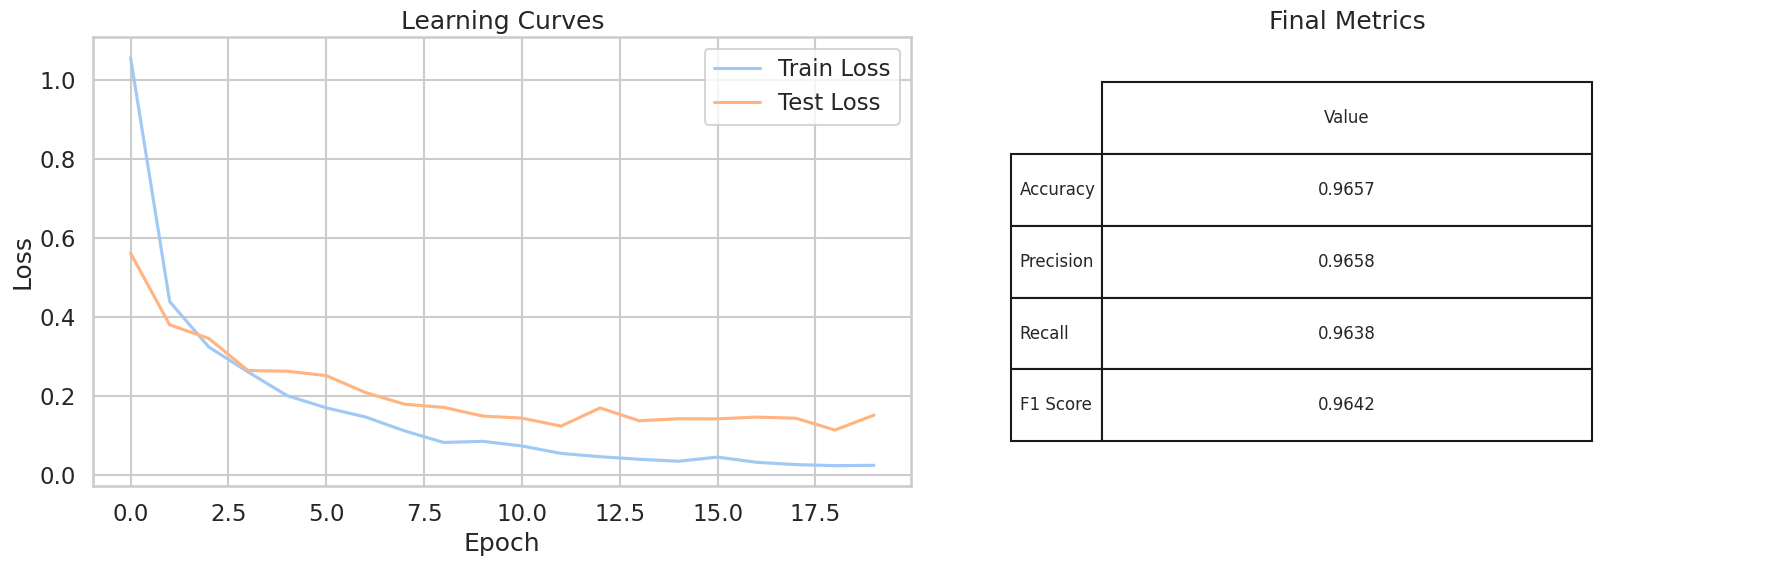

In [13]:
model = Tumor_Classifier2(num_classes=4)
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

trained_model, history = train(
    train_dataloader,
    val_dataloader,
    num_epochs=20,
    model=model,
    optimizer=optimizer,
    criterion=criterion
)

## Transfer Learning with EfficientNet-B0

### Model Adaptation Strategy

---

In [14]:
from torchvision.models import mobilenet_v2, efficientnet_b0

model_efficientnet_b0 = efficientnet_b0(pretrained=True)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 151MB/s]


In [15]:
model_efficientnet_b0

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [19]:
model_efficientnet_b0.features[0][0] = nn.Conv2d(
    in_channels=3,                 
    out_channels=model_efficientnet_b0.features[0][0].out_channels, 
    kernel_size=model_efficientnet_b0.features[0][0].kernel_size, 
    stride=model_efficientnet_b0.features[0][0].stride, 
    padding=model_efficientnet_b0.features[0][0].padding, 
    bias=False
)

model_efficientnet_b0.classifier[1] = nn.Linear(
    in_features=model_efficientnet_b0.classifier[1].in_features, 
    out_features=4, 
    bias=True
)


Epoch 2/6
              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       300
  meningioma       0.99      1.00      1.00       306
     notumor       1.00      1.00      1.00       405
   pituitary       1.00      1.00      1.00       300

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311

--------------------------------------------------

Epoch 4/6
              precision    recall  f1-score   support

      glioma       1.00      0.99      1.00       300
  meningioma       0.99      1.00      1.00       306
     notumor       1.00      1.00      1.00       405
   pituitary       1.00      1.00      1.00       300

    accuracy                           1.00      1311
   macro avg       1.00      1.00      1.00      1311
weighted avg       1.00      1.00      1.00      1311

--------------------------------------------------

Epoch

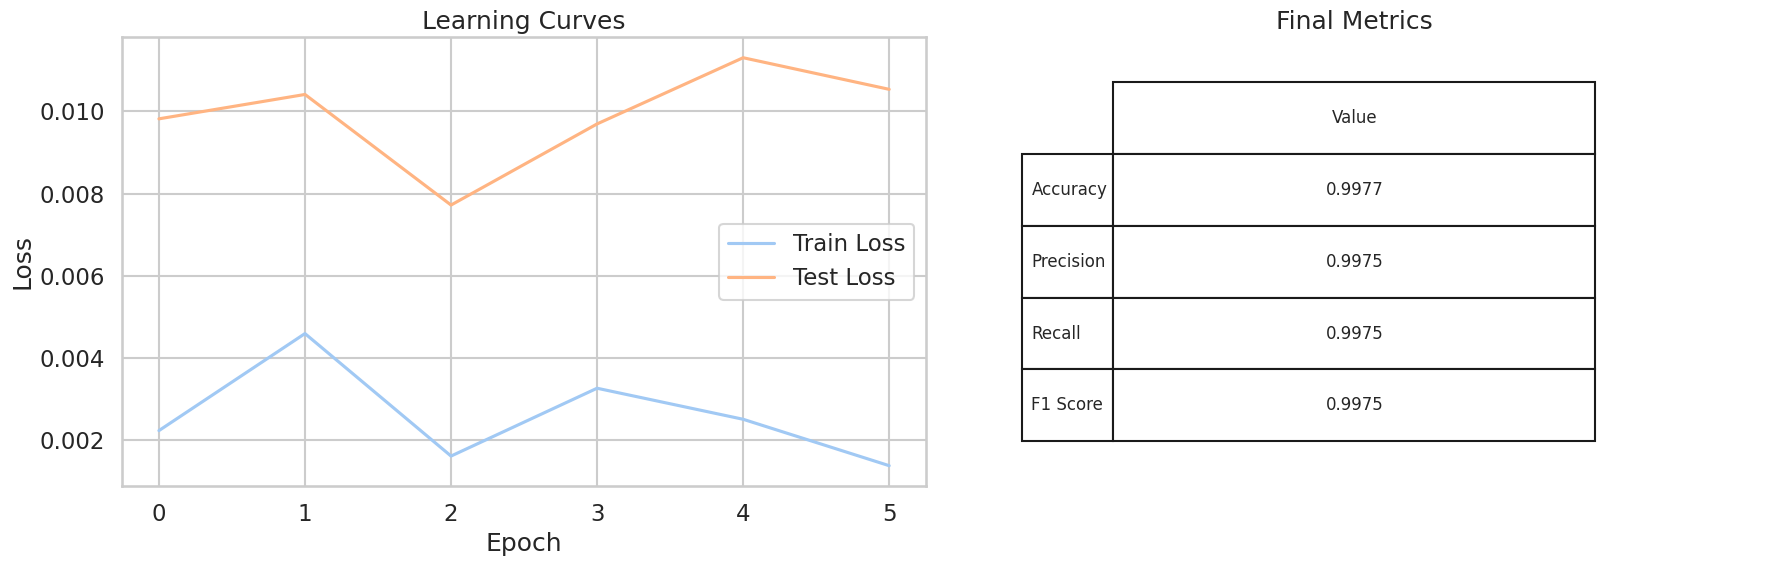

In [25]:
model = model_efficientnet_b0
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

trained_model, history = train(
    train_dataloader,
    val_dataloader,
    num_epochs=6,
    model=model,
    optimizer=optimizer,
    criterion=criterion
)

# 🎯 Conclusion & Future Directions

## 🔑 Key Takeaways
1. **Performance Insights**:
   - Transfer Learning (EfficientNet-B0) achieved **99.7% accuracy** with just 6 epochs
   - Custom CNN (V1) showed good balance: **97.7% accuracy** with 1.2M params
   - Simplified CNN (V2) fastest but prone to underfitting (**96.5% accuracy**
